## Handling Imbalanced Datasets in Classification

**Dataset:** Health insurance customers — predicting who will also buy vehicle insurance.

The target column `Response` is heavily imbalanced: only ~16% of customers said yes.  
A naive model that always predicts "No" would be 84% accurate but completely useless.

**Why accuracy is misleading here:** We care more about catching the "interested" customers (recall) than being conservative (precision). Accuracy hides this.

**4 things to try**
1. Adjust the prediction threshold
2. Oversample — duplicate minority class examples
3. Undersample — remove majority class examples
4. Class weights — penalize minority class mistakes more

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, accuracy_score)
import xgboost as xgb

```About this file
We have information about:

Demographics (gender, age, region code type),
Vehicles (Vehicle Age, Damage),
Policy (Premium, sourcing channel) etc.
target:Response

In [2]:
df = pd.read_csv('aug_train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (382154, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,17163,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,32023,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,87447,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,501933,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0


### Data processing

In [3]:
# no missing values — no imputation needed
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [4]:
df.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [5]:
# Gender, Vehicle_Age, Vehicle_Damage are strings — convert to numbers via one-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Vehicle_Age', 'Vehicle_Damage'])
df.shape

(382154, 16)

In [6]:
df.head(5)

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Female,Gender_Male,Vehicle_Age_1-2 Year,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_No,Vehicle_Damage_Yes
0,167647,22,1,7.0,1,2630.0,152.0,16,0,False,True,False,True,False,True,False
1,17163,42,1,28.0,0,43327.0,26.0,135,0,False,True,True,False,False,False,True
2,32023,66,1,33.0,0,35841.0,124.0,253,0,True,False,True,False,False,False,True
3,87447,22,1,33.0,0,27645.0,152.0,69,0,True,False,False,True,False,True,False
4,501933,28,1,46.0,1,29023.0,152.0,211,0,False,True,False,True,False,True,False


### The Class Imbalance Problem

The target column `Response` tells us if a customer wants vehicle insurance.

Only ~16% said yes. This creates a problem: a model that always predicts "No" would get 84% accuracy but catch zero interested customers. We need to force the model to pay attention to that 16%.

**Metrics:**
- **Precision** — of all customers we predicted as "interested", how many actually were?
- **Recall** — of all customers who are actually interested, how many did we catch?
- **F1** — harmonic mean of precision and recall (one number to compare approaches)

Not Interested (0): 319,553
Interested (1):     62,601

Minority class is only 16.4% of the data


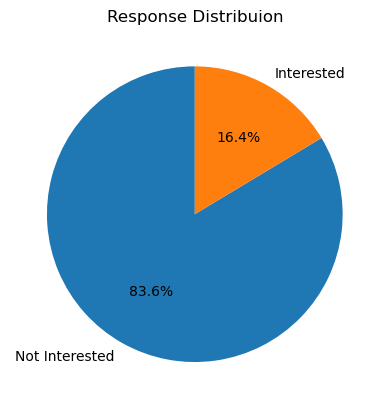

In [7]:
counts = df['Response'].value_counts()
print(f"Not Interested (0): {counts[0]:,}")
print(f"Interested (1):     {counts[1]:,}")
print(f"\nMinority class is only {counts[1]/counts.sum()*100:.1f}% of the data")

counts.plot.pie(labels=['Not Interested', 'Interested'], autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Response Distribuion')
plt.show()

### Train / Test Split

`stratify=y` makes sure both train and test sets have the same ~16/84 class ratio.
Without it, we might accidentally put almost all minority class examples into one set.

**NOTE:** The test set is never modified — it always reflects real-world distribution.
All sampling techniques below only touch the training data.

In [8]:
X = df.drop(columns=['id', 'Response'])
y = df['Response']

# rename columns to remove special characters (XGBoost can be fussy about these)
X.columns = ['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
             'Annual_Premium', 'Policy_Sales_Channel', 'Vintage',
             'Gender_Female', 'Gender_Male', 'Vehicle_Age_1_2_Year',
             'Vehicle_Age_lt_1_Year', 'Vehicle_Age_gt_2_Years',
             'Vehicle_Damage_No', 'Vehicle_Damage_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Minority class in train: {y_train.mean()*100:.2f}%")
print(f"Minority class in test:  {y_test.mean()*100:.2f}%")

Train: 305,723  |  Test: 76,431
Minority class in train: 16.38%
Minority class in test:  16.38%


---
### Confusion Matrix & Evaluation Metrics

#### Confusion Matrix

|                     | **Predicted: Yes (1)** | **Predicted: No (0)** |
|---------------------|------------------------|----------------------|
| **Actual: Yes (1)** | TP (True Positive)     | FN (False Negative)  |
| **Actual: No (0)**  | FP (False Positive)    | TN (True Negative)   |

- **TP** — model said "interested" and the customer actually was
- **TN** — model said "not interested" and the customer actually wasn't
- **FP** — model said "interested" but the customer wasn't *(false alarm)*
- **FN** — model said "not interested" but the customer actually was *(missed opportunity)*


#### Metrics :

**Accuracy** — out of all predictions, how many were correct?
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
> Misleading when classes are imbalanced. A model that always says "No" gets 84% accuracy here.

**Precision** — of all customers we predicted as interested, how many actually were?
$$Precision = \frac{TP}{TP + FP}$$
> High precision = fewer false alarms. Important when contacting uninterested customers is costly.

**Recall** — of all customers who are actually interested, how many did we catch?
$$Recall = \frac{TP}{TP + FN}$$
> High recall = fewer missed opportunities. Important when missing an interested customer is costly.

**F1 Score** — single number that balances precision and recall
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
> Best metric to use when both false positives and false negatives matter.


In [9]:
# helper functions used throughout the notebook

def get_metrics(y_true, y_pred, label):
    return {
        'Model':     label,
        'Precision': np.round(precision_score(y_true, y_pred), 4),
        'Recall':    np.round(recall_score(y_true, y_pred), 4),
        'F1':        np.round(f1_score(y_true, y_pred), 4),
    }

def plot_cm(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.44)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], va='center', ha='center', fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(title, fontsize=13)
    plt.show()

results = []  # track metrics from each approach for final comparison

## Baseline XGBoost Model

Train without any changes first. This tells us where we're starting from.  
High accuracy in this problem does not mean much here — need to focus on F1 score.

In [10]:
model = xgb.XGBClassifier(random_state=123, eval_metric='logloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy: 84.60%


In [12]:
# 84% accuracy looks good but is misleading — the model is mostly just predicting "No"

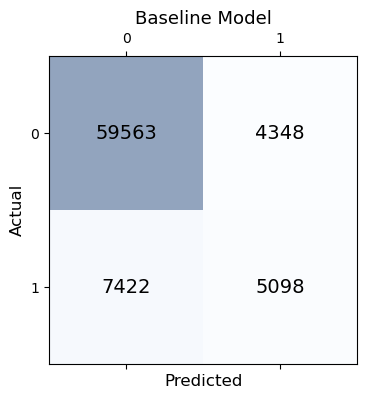

In [13]:
plot_cm(y_test, y_pred, 'Baseline Model')

In [14]:
results.append(get_metrics(y_test, y_pred, 'Baseline'))
pd.DataFrame(results).set_index('Model')

,Precision,Recall,F1
Model,,,
Baseline,0.5397,0.4072,0.4642


In [15]:
# precision 0.54 means 54% of people we targeted were actually interested
# recall 0.41 means we only caught 41% of all interested customers
# there's a lot of room to improve recall without destroying precision

## Fix 1: Adjust the Decision Threshold

XGBoost doesn't directly predict 0 or 1 — it first predicts a probability (0.0 to 1.0).
By default it labels a customer as "interested" only when that probability is ≥ 0.5.

In [16]:
probs = model.predict_proba(X_test)[:, 1]  # probability of class 1 for each test example

rows = []
for t in [i / 20 for i in range(1, 16)]:
    preds = (probs >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Precision': np.round(precision_score(y_test, preds), 4),
        'Recall':    np.round(recall_score(y_test, preds), 4),
        'F1':        np.round(f1_score(y_test, preds), 4),
    })

threshold_df = pd.DataFrame(rows).set_index('Threshold')
threshold_df

,Precision,Recall,F1
Threshold,,,
0.05,0.3579,0.9866,0.5253
0.10,0.3875,0.9629,0.5526
0.15,0.4178,0.9284,0.5763
0.20,0.4447,0.8899,0.5931
0.25,0.4684,0.8505,0.6041
0.30,0.4872,0.8133,0.6094
0.35,0.5014,0.7700,0.6073
0.40,0.5131,0.7135,0.5969
0.45,0.5261,0.6018,0.5614


**Lowering the threshold** (e.g. to 0.3) means we label more customers as "interested".
- More true positives → **higher recall**
- But also more false positives → **lower precision**

This is a trade-off. We sweep through thresholds to find where F1 is best.

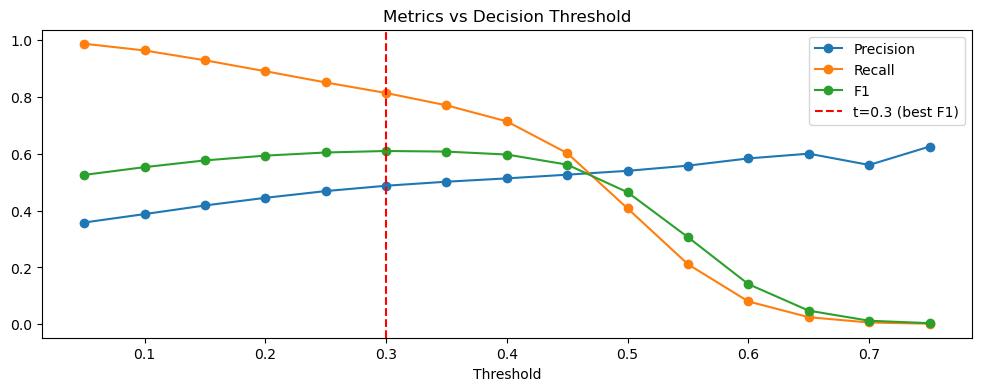

In [17]:
threshold_df.plot(figsize=(12, 4), marker='o', title='Metrics vs Decision Threshold')
plt.axvline(x=0.3, color='red', linestyle='--', label='t=0.3 (best F1)')
plt.xlabel('Threshold')
plt.legend()
plt.show()

Threshold **0.3** gives the best F1 score. Let's evaluate with it.

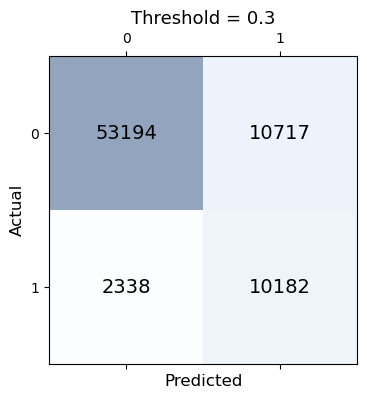

In [18]:
y_pred_t30 = (probs >= 0.3).astype(int)
plot_cm(y_test, y_pred_t30, 'Threshold = 0.3')

In [19]:
results.append(get_metrics(y_test, y_pred_t30, 'Threshold=0.3'))
pd.DataFrame(results).set_index('Model')

,Precision,Recall,F1
Model,,,
Baseline,0.5397,0.4072,0.4642
Threshold=0.3,0.4872,0.8133,0.6094


## Fix 2: Oversampling (Duplicate Minority Class Examples)

**The problem:** The model has seen ~255k "not interested" examples but only ~50k "interested" ones.
It naturally gets better at predicting the majority class because that's most of what it trains on.

**The fix — oversampling:**
We duplicate rows from the minority class (Response=1) over and over until we have as many
as the majority class. Now the model trains on equal numbers of both classes.

```
Before:  [0, 0, 0, 0, 0, 1, 1]  →  imbalanced
After:   [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]  →  balanced (1s were copied)
```

**Limitation:** We're copying the same rows — no new information.
The model might memorize these duplicated examples (overfitting).
A better approach is **SMOTE** (`imbalanced-learn` library), which creates *synthetic* new examples
by interpolating between existing minority class points instead of just copying them.

In [20]:
# combine X_train and y_train into one df so we can split by class label
train_df = pd.concat([X_train, y_train], axis=1)

majority = train_df[train_df.Response == 0]  # rows where customer said No
minority = train_df[train_df.Response == 1]  # rows where customer said Yes

print(f"Before — Majority (0): {len(majority):,}  |  Minority (1): {len(minority):,}")

# randomly duplicate minority rows (replace=True allows picking the same row multiple times)
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=123)
train_up = pd.concat([majority, minority_upsampled])

print(f"After  — Majority (0): {train_up.Response.value_counts()[0]:,}  |  Minority (1): {train_up.Response.value_counts()[1]:,}")

Before — Majority (0): 255,642  |  Minority (1): 50,081
After  — Majority (0): 255,642  |  Minority (1): 255,642


In [21]:
minority.shape, minority_upsampled.shape

((50081, 15), (255642, 15))

In [22]:
X_train_up = train_up.drop(columns=['Response'])
y_train_up = train_up['Response']

model_up = xgb.XGBClassifier(random_state=123, eval_metric='logloss')
model_up.fit(X_train_up, y_train_up)
y_pred_up = model_up.predict(X_test)

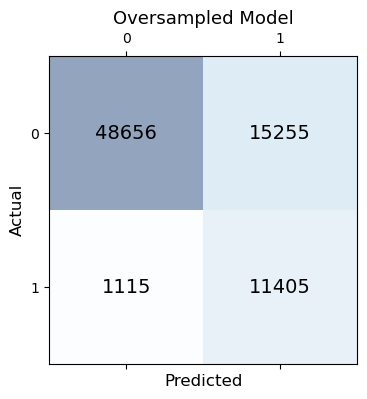

In [23]:
plot_cm(y_test, y_pred_up, 'Oversampled Model')

In [24]:
results.append(get_metrics(y_test, y_pred_up, 'Oversample'))
pd.DataFrame(results).set_index('Model')

,Precision,Recall,F1
Model,,,
Baseline,0.5397,0.4072,0.4642
Threshold=0.3,0.4872,0.8133,0.6094
Oversample,0.4278,0.9109,0.5822


## Fix 3: Undersampling (Remove Majority Class Examples)

**The fix — undersampling:**
Instead of adding minority examples, we randomly *remove* majority class rows until
both classes have the same count. The model then trains on a smaller but balanced dataset.

```
Before:  [0, 0, 0, 0, 0, 1, 1]  →  imbalanced
After:   [0, 0, 1, 1]  →  balanced (some 0s were dropped)
```

**Trade-off:**
- Much less data
- The model trains faster and stops ignoring the minority class
- But we're throwing away real information about the majority class

**When to use:** When you have a large dataset and can afford to discard some majority examples.
The risk is losing signal about edge cases in the majority class.

In [25]:
print(f"Before — Majority (0): {len(majority):,}  |  Minority (1): {len(minority):,}")

# randomly drop majority rows (replace=False means no row is picked twice)
majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=123)
train_down = pd.concat([majority_downsampled, minority])

print(f"After  — Majority (0): {train_down.Response.value_counts()[0]:,}  |  Minority (1): {train_down.Response.value_counts()[1]:,}")

Before — Majority (0): 255,642  |  Minority (1): 50,081
After  — Majority (0): 50,081  |  Minority (1): 50,081


In [26]:
X_train_down = train_down.drop(columns=['Response'])
y_train_down = train_down['Response']

model_down = xgb.XGBClassifier(random_state=123, eval_metric='logloss')
model_down.fit(X_train_down, y_train_down)
y_pred_down = model_down.predict(X_test)

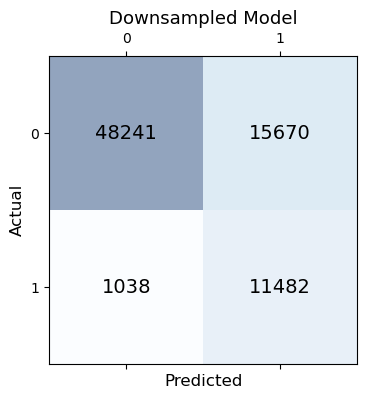

In [27]:
plot_cm(y_test, y_pred_down, 'Downsampled Model')

In [28]:
results.append(get_metrics(y_test, y_pred_down, 'Undersample'))
pd.DataFrame(results).set_index('Model')

,Precision,Recall,F1
Model,,,
Baseline,0.5397,0.4072,0.4642
Threshold=0.3,0.4872,0.8133,0.6094
Oversample,0.4278,0.9109,0.5822
Undersample,0.4229,0.9171,0.5788


## Fix 4: Class Weights

**The idea:** Don't touch the data at all. Instead, tell the model directly that
getting a minority class prediction wrong should cost more.

XGBoost has a `scale_pos_weight` parameter for this. We set it to the ratio of majority to minority:

```
scale_pos_weight = count(Response=0) / count(Response=1)
```

In [29]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Majority/Minority ratio = {ratio:.2f}  →  used as scale_pos_weight")

model_cw = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=123, eval_metric='logloss')
model_cw.fit(X_train, y_train)
y_pred_cw = model_cw.predict(X_test)

Majority/Minority ratio = 5.10  →  used as scale_pos_weight


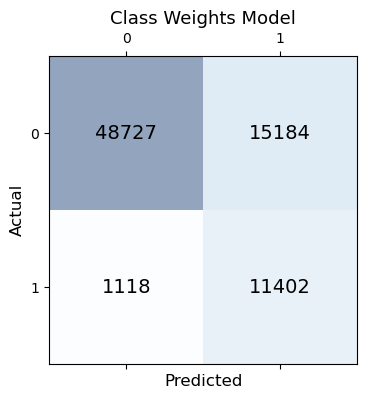

In [30]:
plot_cm(y_test, y_pred_cw, 'Class Weights Model')

In [31]:
results.append(get_metrics(y_test, y_pred_cw, 'Class Weights'))
pd.DataFrame(results).set_index('Model')

,Precision,Recall,F1
Model,,,
Baseline,0.5397,0.4072,0.4642
Threshold=0.3,0.4872,0.8133,0.6094
Oversample,0.4278,0.9109,0.5822
Undersample,0.4229,0.9171,0.5788
Class Weights,0.4289,0.9107,0.5831


               Precision  Recall      F1
Model                                   
Baseline          0.5397  0.4072  0.4642
Threshold=0.3     0.4872  0.8133  0.6094
Oversample        0.4278  0.9109  0.5822
Undersample       0.4229  0.9171  0.5788
Class Weights     0.4289  0.9107  0.5831


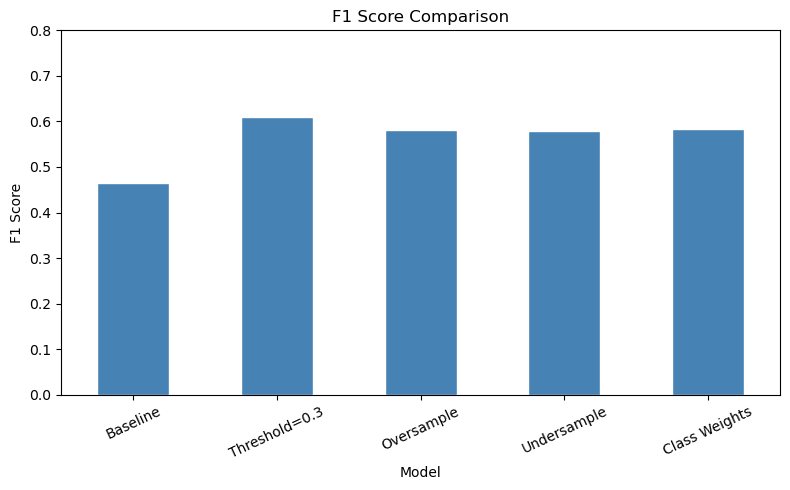

In [32]:
final = pd.DataFrame(results).set_index('Model')
print(final.to_string())

final['F1'].plot(kind='bar', color='steelblue', edgecolor='white',
                 figsize=(8, 5), title='F1 Score Comparison', rot=25)
plt.ylabel('F1 Score')
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()